# DBSCAN Klaszterezés (campaign, duration)

In [1]:
# Alapvető könyvtárak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Sklearn könyvtárak
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Matplotlib beállítások
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Adathalmaz beolvasása
root = r"bank+marketing\bank\bank-full.csv"
df = pd.read_csv(root, sep=';')

print("="*70)
print("ADATOK BETÖLTÉSE")
print("="*70)
print(f"Sorok száma: {len(df):,}")
print(f"Oszlopok száma: {len(df.columns)}")
print("\nElső 5 sor (campaign, duration):")
print(df[['campaign', 'duration']].head())
print("\nStatisztikák:")
print(df[['campaign', 'duration']].describe())

ADATOK BETÖLTÉSE
Sorok száma: 45,211
Oszlopok száma: 17

Első 5 sor (campaign, duration):
   campaign  duration
0         1       261
1         1       151
2         1        76
3         1        92
4         1       198

Statisztikák:
           campaign      duration
count  45211.000000  45211.000000
mean       2.763841    258.163080
std        3.098021    257.527812
min        1.000000      0.000000
25%        1.000000    103.000000
50%        2.000000    180.000000
75%        3.000000    319.000000
max       63.000000   4918.000000


In [3]:
# Feature Selection: campaign és duration
features = ['campaign', 'duration']
X = df[features].copy()

print("\n" + "="*70)
print("FEATURE SELECTION ÉS NORMALIZÁLÁS")
print("="*70)
print(f"Kiválasztott változók: {features}")
print(f"Adatpontok száma: {len(X):,}")
print(f"Dimenziószám: {X.shape[1]}")

# Normalizálás: StandardScaler (KRITIKUS DBSCAN-hez!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n✓ Adatok normalizálva (StandardScaler)!")
print(f"  X_scaled alakja: {X_scaled.shape}")
print(f"  Átlag: {X_scaled.mean(axis=0)}")
print(f"  Szórás: {X_scaled.std(axis=0)}")


FEATURE SELECTION ÉS NORMALIZÁLÁS
Kiválasztott változók: ['campaign', 'duration']
Adatpontok száma: 45,211
Dimenziószám: 2

✓ Adatok normalizálva (StandardScaler)!
  X_scaled alakja: (45211, 2)
  Átlag: [3.01750028e-17 6.03500056e-17]
  Szórás: [1. 1.]


In [ ]:
def calculate_gini_coefficient(cluster_sizes):
    """
    Gini együttható kiszámítása a klaszter-méretek egyenlőtlenségének mérésére.
    
    Gini = 0: tökéletesen egyenlő eloszlás
    Gini = 1: maximális egyenlőtlenség (minden egy klaszterben)
    
    Kisebb Gini = jobb (egyenletesebb klaszter-méretek)
    """
    if len(cluster_sizes) == 0:
        return 1.0
    
    cluster_sizes = np.array(sorted(cluster_sizes))
    n = len(cluster_sizes)
    index = np.arange(1, n + 1)
    gini = (2 * np.sum(index * cluster_sizes)) / (n * np.sum(cluster_sizes)) - (n + 1) / n
    return gini

# Célzott klaszter-szám preferencia: 3-8 klaszter
def calculate_balance_score(labels):
    cluster_labels = labels[labels != -1]
    if len(cluster_labels) == 0:
        return 0.0
    
    unique_labels, counts = np.unique(cluster_labels, return_counts=True)
    n_clusters = len(unique_labels)
    
    # KRITIKUS: Klaszter-szám penalty
    if n_clusters < 3:
        cluster_count_score = 0.3  # Túl kevés
    elif 3 <= n_clusters <= 8:
        cluster_count_score = 1.0  # IDEÁLIS TARTOMÁNY
    elif 9 <= n_clusters <= 20:
        cluster_count_score = 0.6  # Elfogadható
    else:
        cluster_count_score = 0.1  # TÚL SOK - erős büntetés
    
    # Gini (egyenlőtlenség)
    gini = calculate_gini_coefficient(counts)
    gini_score = 1 - gini
    
    # Legnagyobb klaszter aránya
    largest_ratio = counts.max() / len(cluster_labels)
    
    # MÓDOSÍTOTT logika:
    # - Ha 30-70% között van a legnagyobb → OK (0.8-1.0)
    # - Ha >80% → rossz (0.0-0.2)
    # - Ha <20% → túl fragmentált (0.3-0.5)
    if 0.3 <= largest_ratio <= 0.7:
        largest_score = 1.0
    elif 0.2 <= largest_ratio < 0.3:
        largest_score = 0.7
    elif largest_ratio > 0.8:
        largest_score = 0.1
    else:
        largest_score = 0.4  # Túl kicsi is rossz
    
    # SÚLYOZÁS:
    # 50% klaszter-szám (legfontosabb!)
    # 30% legnagyobb klaszter mérete
    # 20% gini
    duration_score = (0.5 * cluster_count_score + 
                    0.3 * largest_score + 
                    0.2 * gini_score)
    
    return duration_score

✓ Klaszter-eloszlás egyensúly függvények definiálva!


In [5]:
# k-distance számítása több MinPts értékre
print("="*70)
print("K-DISTANCE GRAPH SZÁMÍTÁSA")
print("="*70)

minpts_values = [4, 10, 20]
k_distances_dict = {}

for min_pts in minpts_values:
    neighbors = NearestNeighbors(n_neighbors=min_pts)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    k_distances = distances[:, -1]
    k_distances_dict[min_pts] = k_distances
    
    print(f"\nMinPts = {min_pts}:")
    print(f"  50%: {np.percentile(k_distances, 50):.4f}")
    print(f"  75%: {np.percentile(k_distances, 75):.4f}")
    print(f"  90%: {np.percentile(k_distances, 90):.4f}")
    print(f"  95%: {np.percentile(k_distances, 95):.4f}")
    print(f"  99%: {np.percentile(k_distances, 99):.4f}")

print("\n✓ k-distance értékek kiszámítva!")

K-DISTANCE GRAPH SZÁMÍTÁSA

MinPts = 4:
  50%: 0.0000
  75%: 0.0000
  90%: 0.0039
  95%: 0.0116
  99%: 0.0932

MinPts = 10:
  50%: 0.0000
  75%: 0.0039
  90%: 0.0116
  95%: 0.0311
  99%: 0.2986

MinPts = 20:
  50%: 0.0039
  75%: 0.0078
  90%: 0.0272
  95%: 0.0699
  99%: 0.3473

✓ k-distance értékek kiszámítva!


In [6]:
# SZÉLES KÖRŰ PARAMÉTER TESZTELÉS
print("\n" + "="*100)
print("DBSCAN SZÉLES KÖRŰ PARAMÉTER TESZTELÉS")
print("="*100)

all_results = []

for min_pts in minpts_values:
    k_distances = k_distances_dict[min_pts]
    
    # Epsilon értékek kiszámítása
    percentiles = [50, 60, 70, 75, 80, 85, 90, 95, 97, 99]
    epsilon_values = [np.percentile(k_distances, p) for p in percentiles]
    
    # ===== KRITIKUS FIX: Epsilon validálás =====
    # Ha az epsilon 0.0 vagy túl kicsi, használj minimum értéket
    MIN_EPSILON = 1e-6  # Nagyon kicsi pozitív szám
    
    epsilon_values_fixed = []
    percentiles_fixed = []
    
    for eps, pct in zip(epsilon_values, percentiles):
        if eps <= MIN_EPSILON:
            print(f"⚠ Kihagyva: MinPts={min_pts}, {pct}. percentilis, ε={eps:.6f} (túl kicsi)")
            continue  # Kihagyjuk ezt az epsilon értéket
        else:
            epsilon_values_fixed.append(eps)
            percentiles_fixed.append(pct)
    
    if len(epsilon_values_fixed) == 0:
        print(f"⚠ MinPts={min_pts}: NINCS ÉRVÉNYES EPSILON! Átugorva.")
        continue
    # ==========================================
    
    print(f"\n{'='*100}")
    print(f"MinPts = {min_pts}, Érvényes epsilon értékek: {len(epsilon_values_fixed)}")
    print(f"{'='*100}")
    
    for eps, pct in zip(epsilon_values_fixed, percentiles_fixed):
        # DBSCAN futtatása (most már eps > 0 garantált)
        dbscan = DBSCAN(eps=eps, min_samples=min_pts)
        labels = dbscan.fit_predict(X_scaled)
        
        # Statisztikák
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        noise_ratio = n_noise / len(labels) * 100
        n_core = len(dbscan.core_sample_indices_)
        
        # Klaszter-eloszlás elemzés
        cluster_labels = labels[labels != -1]
        if len(cluster_labels) > 0:
            unique_labels, counts = np.unique(cluster_labels, return_counts=True)
            largest_cluster_pct = counts.max() / len(cluster_labels) * 100 if len(counts) > 0 else 0
        else:
            largest_cluster_pct = 0
        
        # Validációs metrikák
        if n_clusters >= 2 and noise_ratio < 50:
            mask = labels != -1
            if mask.sum() > 1:
                try:
                    silhouette = silhouette_score(X_scaled[mask], labels[mask])
                    davies_bouldin = davies_bouldin_score(X_scaled[mask], labels[mask])
                    calinski = calinski_harabasz_score(X_scaled[mask], labels[mask])
                except:
                    silhouette = davies_bouldin = calinski = np.nan
            else:
                silhouette = davies_bouldin = calinski = np.nan
        else:
            silhouette = davies_bouldin = calinski = np.nan
        
        # Balance score
        balance_score = calculate_balance_score(labels)
        
        # Combined score
        if not np.isnan(silhouette) and balance_score > 0:
            silhouette_normalized = (silhouette + 1) / 2
            combined_score = 0.3 * silhouette_normalized + 0.7 * balance_score
        else:
            combined_score = 0
        
        all_results.append({
            'min_pts': min_pts,
            'epsilon': eps,
            'percentile': pct,
            'n_clusters': n_clusters,
            'n_core': n_core,
            'n_noise': n_noise,
            'noise_ratio': noise_ratio,
            'largest_cluster_pct': largest_cluster_pct,
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski,
            'balance_score': balance_score,
            'combined_score': combined_score,
            'labels': labels,
            'dbscan': dbscan
        })
        
        # Kimenet
        status = "✓" if noise_ratio <= 20 and 20 <= largest_cluster_pct < 85 and 2 <= n_clusters <= 20 else "⚠"
        silh_str = f"{silhouette:.3f}" if not np.isnan(silhouette) else "  N/A"
        print(f"ε={eps:.4f} ({pct:>2}%): Klaszter={n_clusters:3d}, Noise={noise_ratio:5.1f}%, "
              f"Max={largest_cluster_pct:5.1f}%, Balance={balance_score:.3f}, "
              f"Silh={silh_str:>5s}, Combined={combined_score:.3f} {status}")

print(f"\n✓ Összesen {len(all_results)} konfiguráció tesztelve!")


DBSCAN SZÉLES KÖRŰ PARAMÉTER TESZTELÉS
⚠ Kihagyva: MinPts=4, 50. percentilis, ε=0.000000 (túl kicsi)
⚠ Kihagyva: MinPts=4, 60. percentilis, ε=0.000000 (túl kicsi)
⚠ Kihagyva: MinPts=4, 70. percentilis, ε=0.000000 (túl kicsi)
⚠ Kihagyva: MinPts=4, 75. percentilis, ε=0.000000 (túl kicsi)
⚠ Kihagyva: MinPts=4, 80. percentilis, ε=0.000000 (túl kicsi)

MinPts = 4, Érvényes epsilon értékek: 5
ε=0.0039 (85%): Klaszter=2388, Noise= 11.9%, Max=  0.4%, Balance=0.277, Silh=0.894, Combined=0.478 ⚠
ε=0.0039 (90%): Klaszter=599, Noise=  7.3%, Max= 37.3%, Balance=0.369, Silh=0.165, Combined=0.433 ⚠
ε=0.0116 (95%): Klaszter=283, Noise=  4.1%, Max= 39.3%, Balance=0.361, Silh=0.098, Combined=0.417 ⚠
ε=0.0194 (97%): Klaszter=195, Noise=  2.5%, Max= 39.4%, Balance=0.359, Silh=0.091, Combined=0.415 ⚠
ε=0.0932 (99%): Klaszter= 78, Noise=  0.8%, Max= 39.0%, Balance=0.363, Silh=0.098, Combined=0.419 ⚠
⚠ Kihagyva: MinPts=10, 50. percentilis, ε=0.000000 (túl kicsi)
⚠ Kihagyva: MinPts=10, 60. percentilis, ε=0.0

In [7]:
# OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA
print("\n" + "="*100)
print("OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA")
print("="*100)

# Szűrés: SZIGORÚ kritériumok a használható eredményekhez
valid_results = [
    r for r in all_results 
    if r['noise_ratio'] <= 25        
    and r['largest_cluster_pct'] < 50  
    and r['n_clusters'] >= 2          
    and r['n_clusters'] <= 100        
    and not np.isnan(r['silhouette'])
]

print(f"\nSzűrési kritériumok:")
print(f"  - Noise arány ≤ 20%")
print(f"  - Legnagyobb klaszter 20-85% között")
print(f"  - Klaszterek száma: 2-20")
print(f"  - Silhouette Score létezik")
print(f"\nMegfelelő konfigurációk száma: {len(valid_results)}")

if len(valid_results) > 0:
    # 5 legjobb kombinált score
    top5 = sorted(valid_results, key=lambda x: x['combined_score'], reverse=True)[:5]
    
    print("\n" + "="*100)
    print("5 LEGJOBB KONFIGURÁCIÓ (kombinált score alapján)")
    print("="*100)
    print(f"{'Rang':<5} {'MinPts':<8} {'ε':<10} {'Klaszter':<10} {'Noise%':<8} {'MaxKlasz%':<10} "
          f"{'Silh':<8} {'Balance':<9} {'Combined':<9}")
    print("-" * 100)
    
    for i, r in enumerate(top5, 1):
        print(f"{i:<5} {r['min_pts']:<8} {r['epsilon']:<10.4f} {r['n_clusters']:<10} "
              f"{r['noise_ratio']:<8.2f} {r['largest_cluster_pct']:<10.1f} "
              f"{r['silhouette']:<8.4f} {r['balance_score']:<9.4f} {r['combined_score']:<9.4f}")
    
    # Legjobb kiválasztása
    optimal_result = top5[0]
    
    print("\n" + "="*100)
    print("OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTVA")
    print("="*100)
    print(f"MinPts:                 {optimal_result['min_pts']}")
    print(f"Epsilon (ε):            {optimal_result['epsilon']:.4f} ({optimal_result['percentile']}. percentilis)")
    print(f"Klaszterek száma:       {optimal_result['n_clusters']}")
    print(f"Noise arány:            {optimal_result['noise_ratio']:.2f}% ✓")
    print(f"Legnagyobb klaszter:    {optimal_result['largest_cluster_pct']:.1f}% ✓")
    print(f"Silhouette Score:       {optimal_result['silhouette']:.4f}")
    print(f"Davies-Bouldin Index:   {optimal_result['davies_bouldin']:.4f}")
    print(f"Calinski-Harabasz:      {optimal_result['calinski_harabasz']:.2f}")
    print(f"Balance Score:          {optimal_result['balance_score']:.4f}")
    print(f"Combined Score:         {optimal_result['combined_score']:.4f}")
    print("="*100)
    
else:
    print("\nFIGYELMEZTETÉS: Nincs olyan konfiguráció, amely megfelel a kritériumoknak!")
    print("\nLegalacsonyabb noise arányú konfiguráció választása...")
    optimal_result = min(all_results, key=lambda x: x['noise_ratio'])
    print(f"\nKiválasztva: MinPts={optimal_result['min_pts']}, ε={optimal_result['epsilon']:.4f}")
    print(f"  Noise: {optimal_result['noise_ratio']:.2f}%")
    print(f"  Klaszterek: {optimal_result['n_clusters']}")

# Címkék hozzáadása az adathalmazhoz
optimal_labels = optimal_result['labels']
optimal_dbscan = optimal_result['dbscan']
optimal_eps = optimal_result['epsilon']
optimal_min_pts = optimal_result['min_pts']

df['cluster'] = optimal_labels


OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTÁSA

Szűrési kritériumok:
  - Noise arány ≤ 20%
  - Legnagyobb klaszter 20-85% között
  - Klaszterek száma: 2-20
  - Silhouette Score létezik

Megfelelő konfigurációk száma: 11

5 LEGJOBB KONFIGURÁCIÓ (kombinált score alapján)
Rang  MinPts   ε          Klaszter   Noise%   MaxKlasz%  Silh     Balance   Combined 
----------------------------------------------------------------------------------------------------
1     20       0.1476     24         2.47     39.5       0.1034   0.3846    0.4348   
2     10       0.2986     31         0.77     39.1       0.1319   0.3780    0.4344   
3     20       0.0699     28         4.34     40.2       0.0983   0.3790    0.4300   
4     20       0.0078     47         17.00    43.0       0.0883   0.3718    0.4235   
5     20       0.0272     31         8.85     41.6       0.0708   0.3754    0.4234   

OPTIMÁLIS KONFIGURÁCIÓ KIVÁLASZTVA
MinPts:                 20
Epsilon (ε):            0.1476 (97. percentilis)
Klaszterek 

In [8]:
# KLASZTER PROFILOK RÉSZLETES ELEMZÉSE
print("\n" + "="*100)
print("KLASZTER PROFILOK RÉSZLETES ELEMZÉSE")
print("="*100)

profile_data = []

for cluster_id in sorted(df['cluster'].unique()):
    cluster_df = df[df['cluster'] == cluster_id]
    
    profile_data.append({
        'Klaszter': 'Noise' if cluster_id == -1 else f'Cluster_{cluster_id}',
        'Klaszter_ID': cluster_id,
        'Elemszám (db)': len(cluster_df),
        'Elemszám (%)': len(cluster_df) / len(df) * 100,
        'Átlag campaign': cluster_df['campaign'].mean(),
        'Átlag duration': cluster_df['duration'].mean(),
        'Min campaign': cluster_df['campaign'].min(),
        'Max campaign': cluster_df['campaign'].max(),
       'Min duration': cluster_df['duration'].min(),     
    'Max duration': cluster_df['duration'].max()      
    })

profile_df = pd.DataFrame(profile_data)
profile_df = profile_df.sort_values('Elemszám (db)', ascending=False).reset_index(drop=True)

print("\nKlaszter profilok:")
print(profile_df.to_string(index=False))

# CSV exportálás
profile_df.to_csv('exports_dbscan_v3/dbscan_v3_cluster_profiles.csv', index=False)
print("\n✓ Klaszter profilok exportálva: exports_dbscan_v3/dbscan_v3_cluster_profiles.csv")


KLASZTER PROFILOK RÉSZLETES ELEMZÉSE

Klaszter profilok:
  Klaszter  Klaszter_ID  Elemszám (db)  Elemszám (%)  Átlag campaign  Átlag duration  Min campaign  Max campaign  Min duration  Max duration
 Cluster_0            0          17423     38.537082        1.000000      250.726568             1             1             1          1344
 Cluster_1            1          12423     27.477826        2.000000      264.647992             2             2             0          1476
 Cluster_3            3           5461     12.078919        3.000000      256.040469             3             3             2          1297
 Cluster_5            5           3438      7.604344        4.000000      225.296684             4             4             0          1064
 Cluster_4            4           1672      3.698215        5.000000      184.277512             5             5             6           747
 Cluster_6            6           1222      2.702882        6.000000      171.824877            

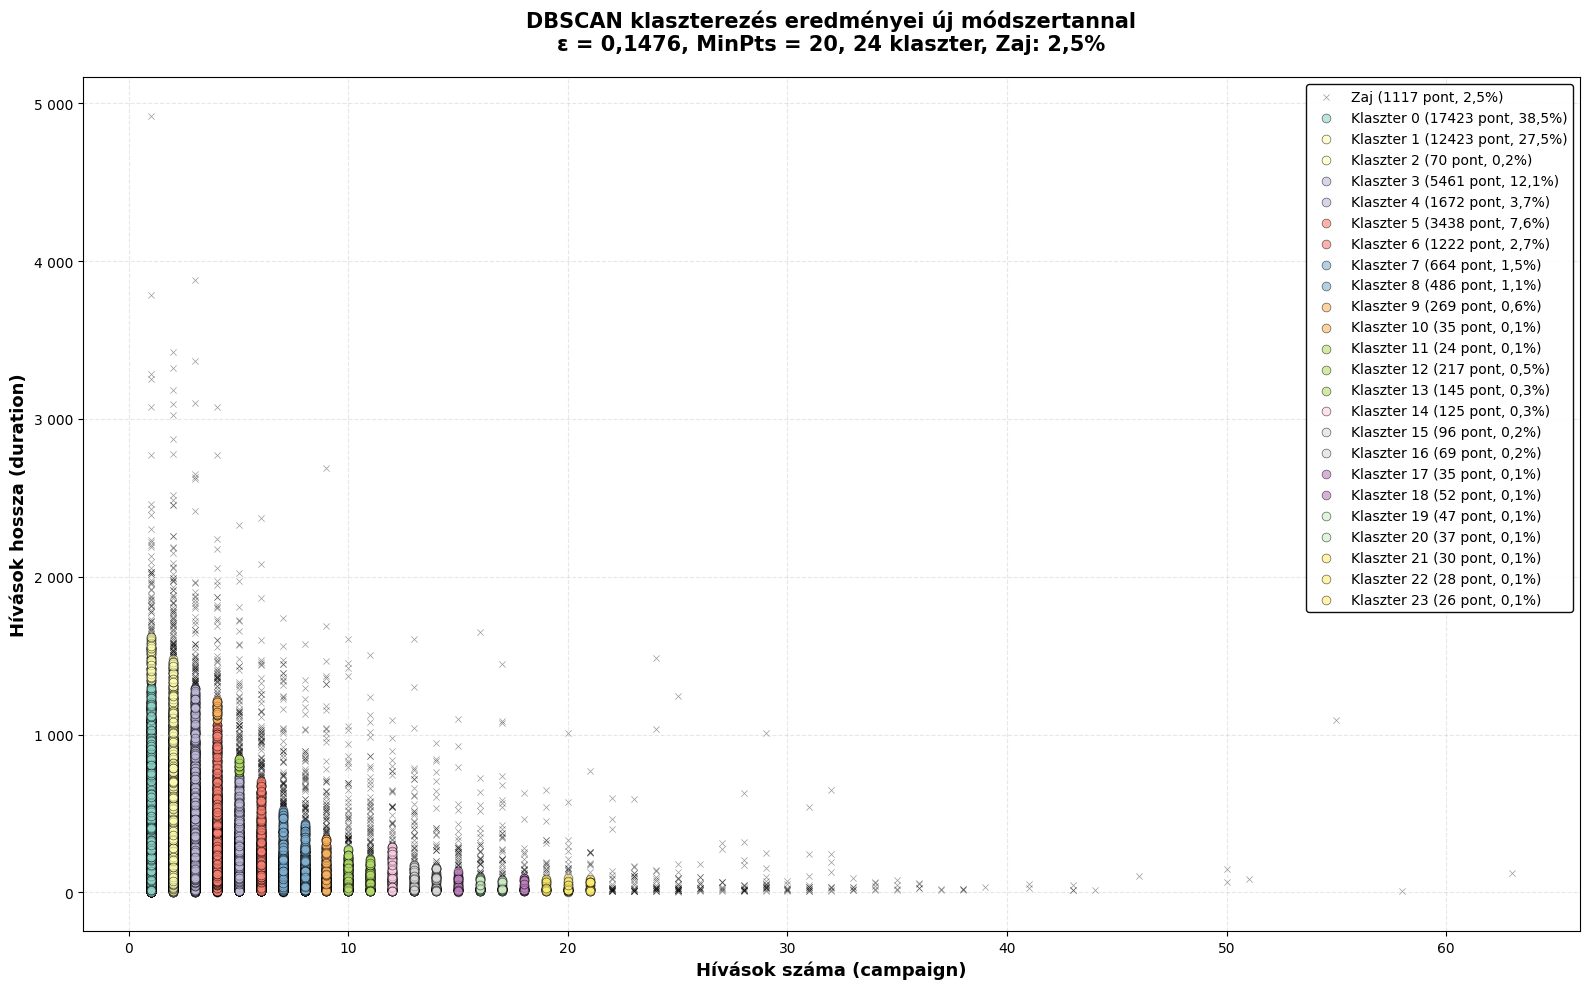

✓ Scatter plot mentve: exports_dbscan_v3/dbscan_v3_scatter_plot.png


In [9]:
# Scatter plot - Campaign vs DUration (DBSCAN klaszterek)
fig, ax = plt.subplots(figsize=(16, 10))

# Színek: noise = fekete, klaszterek = színesek
unique_labels = sorted(set(optimal_labels))
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_labels)))

for idx, cluster_id in enumerate(unique_labels):
    cluster_data = df[df['cluster'] == cluster_id]
    
    if cluster_id == -1:
        # Noise pontok - fekete
        ax.scatter(cluster_data['campaign'], cluster_data['duration'], 
                  label=f'Zaj ({len(cluster_data):} pont, {len(cluster_data)/len(df)*100:.1f}%)'.replace('.',','), 
                  alpha=0.4, s=20, c='black', marker='x', linewidths=0.5)
    else:
        # Klaszter pontok
        ax.scatter(cluster_data['campaign'], cluster_data['duration'], 
                  label=f'Klaszter {cluster_id} ({len(cluster_data):} pont, {len(cluster_data)/len(df)*100:.1f}%)'.replace('.',','), 
                  alpha=0.6, s=40, c=[colors[idx]], edgecolors='black', linewidths=0.5)

# Core pontok kiemelése (nagyobb marker)
core_mask = np.zeros(len(df), dtype=bool)
core_mask[optimal_dbscan.core_sample_indices_] = True
core_points = df[core_mask]


ax.set_xlabel('Hívások száma (campaign)', fontsize=13, fontweight='bold')
ax.set_ylabel('Hívások hossza (duration)', fontsize=13, fontweight='bold')
ax.set_title(f'DBSCAN klaszterezés eredményei új módszertannal\n' + 
            f'ε = {optimal_eps:.4f}, '.replace('.',',') +
            f'MinPts = {min_pts}, ' +
            f'{optimal_result["n_clusters"]} klaszter, ' +
            f'Zaj: {optimal_result["noise_ratio"]:.1f}%'.replace('.',','), 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')

# Y tengely formázása
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', ' ')))

plt.tight_layout()
plt.savefig('exports_dbscan_v3/dbscan_v3_scatter_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Scatter plot mentve: exports_dbscan_v3/dbscan_v3_scatter_plot.png")

In [12]:
# ÖSSZEHASONLÍTÓ TÁBLÁZAT: Összes tesztelt konfiguráció
comparison_df = pd.DataFrame([{
    'MinPts': r['min_pts'],
    'Epsilon': r['epsilon'],
    'Percentilis': r['percentile'],
    'Klaszterek': r['n_clusters'],
    'Noise (%)': r['noise_ratio'],
    'Max Klaszter (%)': r['largest_cluster_pct'],
    'Silhouette': r['silhouette'],
    'Davies-Bouldin': r['davies_bouldin'],
    'Calinski-Harabasz': r['calinski_harabasz'],
    'Balance Score': r['balance_score'],
    'Combined Score': r['combined_score']
} for r in all_results])

comparison_df = comparison_df.sort_values('Combined Score', ascending=False)
comparison_df.to_csv('exports_dbscan_v3/dbscan_v3_all_configurations.csv', index=False)

print("\n✓ Összes konfiguráció exportálva: exports_dbscan_v3/dbscan_v3_all_configurations.csv")
print(f"  Összesen {len(comparison_df)} konfiguráció")


✓ Összes konfiguráció exportálva: exports_dbscan_v3/dbscan_v3_all_configurations.csv
  Összesen 23 konfiguráció


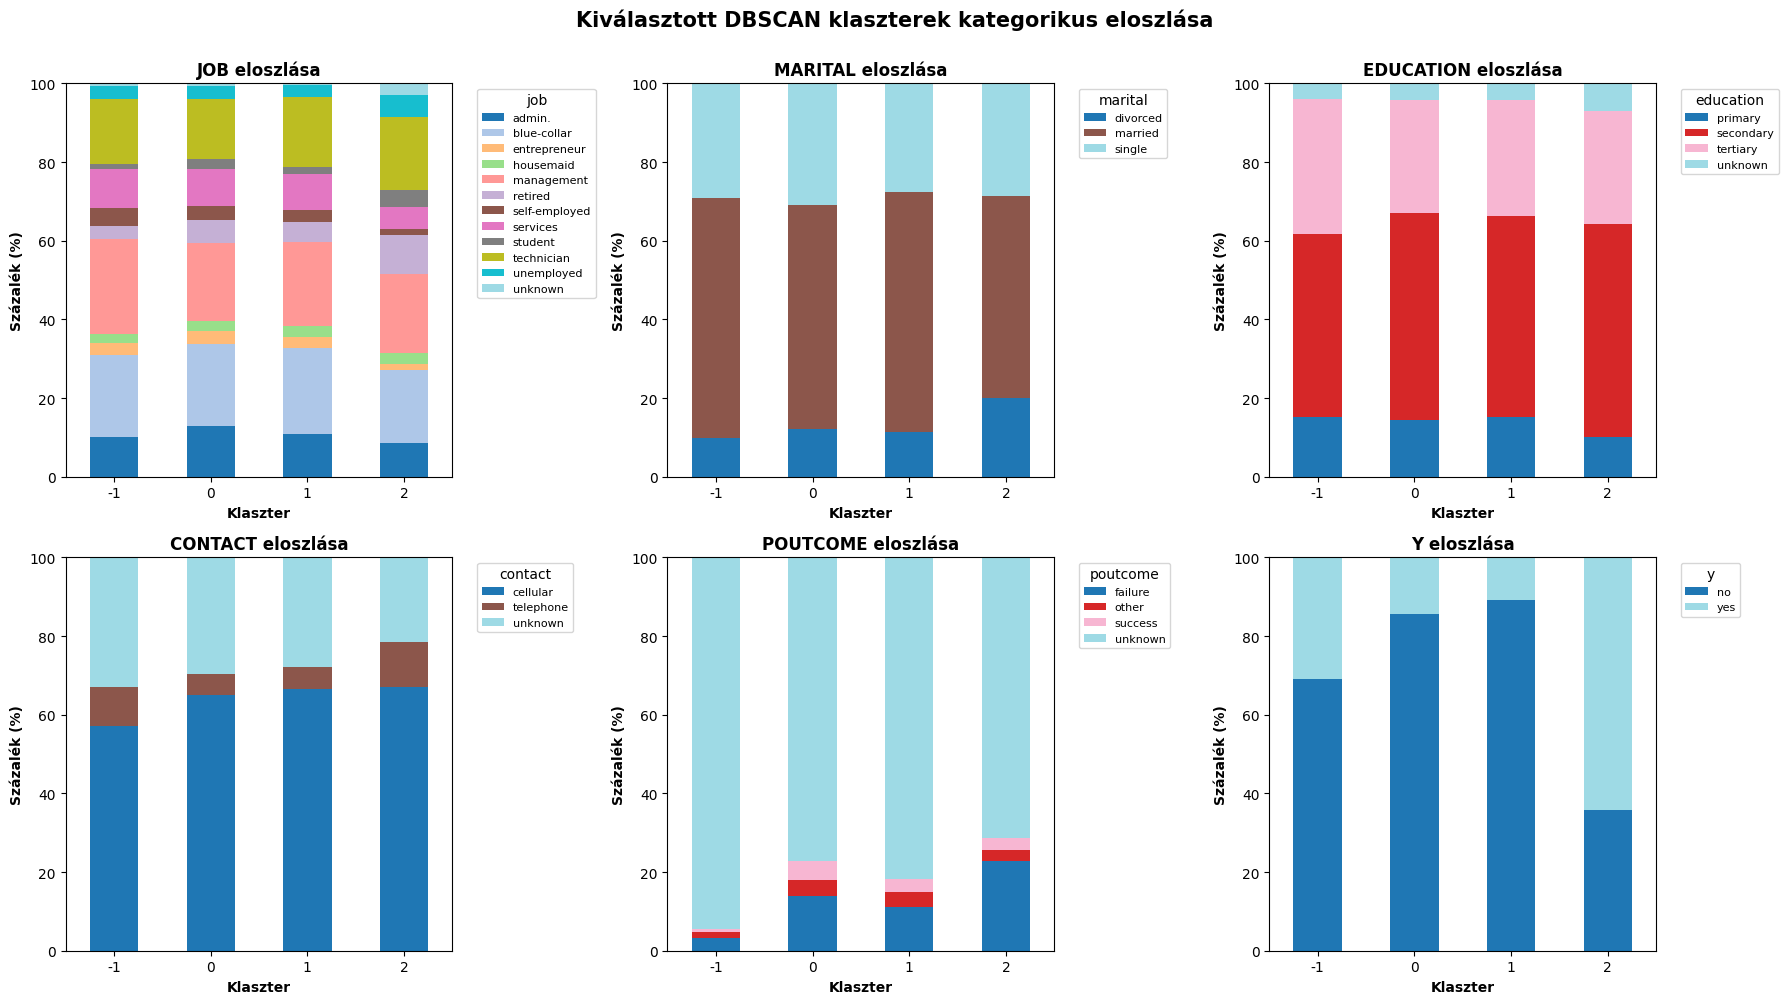

In [13]:
selected_clusters = [-1, 0, 1, 2] 

df_filtered = df[df['cluster'].isin(selected_clusters)].copy()

important_categorical = ['job', 'marital', 'education', 'contact', 'poutcome', 'y']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(important_categorical):
    ax = axes[idx]
    
    crosstab = pd.crosstab(df_filtered['cluster'], df_filtered[col], normalize='index') * 100
    
    crosstab.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
    
    ax.set_title(f'{col.upper()} eloszlása', fontsize=12, fontweight='bold')
    ax.set_xlabel('Klaszter', fontsize=10, fontweight='bold')
    ax.set_ylabel('Százalék (%)', fontsize=10, fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.set_ylim([0, 100])

plt.suptitle('Kiválasztott DBSCAN klaszterek kategorikus eloszlása', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()

plt.show()

In [14]:
# Átfogó profil a kiemelt DBSCAN klaszterekhez (-1, 0, 1, 2)
print("\n" + "="*100)
print("DBSCAN KIEMELT KLASZTEREK RÉSZLETES ÖSSZEFOGLALÁSA (Kritikai elemzés)")
print("="*100)

# Csak a meghatározott klaszter-azonosítókra szűrünk
target_clusters = [-1, 0, 1, 2]

for cluster_id in target_clusters:
    # Ellenőrizzük, hogy létezik-e az adott klaszter az adatokban
    if cluster_id not in df['cluster'].unique():
        continue
        
    cluster_data = df[df['cluster'] == cluster_id]
    
    print(f"\n{'='*100}")
    # Megnevezzük a -1-et külön, mint 'Zaj / Anomália'
    cluster_name = "ZAJ / ANOMÁLIA" if cluster_id == -1 else f"KLASZTER {cluster_id}"
    print(f"{cluster_name} - {len(cluster_data):,} ügyfél ({len(cluster_data)/len(df)*100:.1f}%)".replace(',', ' ').replace('.', ','))
    print(f"{'='*100}")
    
    # Statikus (Demográfiai) változók
    print("\nStatikus (Demográfiai/Állapotjelző) változók:")
    print(f"  Átlagos életkor:   {cluster_data['age'].mean():>8.1f} év (±{cluster_data['age'].std():.1f})".replace('.', ','))
    print(f"  Átlagos egyenleg:  {cluster_data['balance'].mean():>8,.0f} € (±{cluster_data['balance'].std():,.0f})".replace(',', ' ').replace('.', ','))
    
    # Dinamikus (Viselkedési) jellemzők
    print("\nDinamikus (Interakciós/Viselkedési) változók:")
    print(f"  Átlagos hívás időtartam:  {cluster_data['duration'].mean():>6.0f} mp (±{cluster_data['duration'].std():.0f})".replace('.', ','))
    print(f"  Kampány kapcsolatok száma: {cluster_data['campaign'].mean():>6.1f} (±{cluster_data['campaign'].std():.1f})".replace('.', ','))
    
    # Kategorikus jellemzők (A homogenitás vizsgálatához)
    print("\n KATEGORIKUS PROFIL (Homogenitás ellenőrzése):")
    
    top_job = cluster_data['job'].value_counts().head(2)
    print(f"  Fő foglalkozási körök:")
    for job, count in top_job.items():
        print(f"    - {job}: {count} ({count/len(cluster_data)*100:.1f}%)".replace('.', ','))
    
    # Konverziós arány - A legfontosabb üzleti mutató
    conversion_rate = (cluster_data['y'] == 'yes').sum() / len(cluster_data) * 100
    print(f"\n ÜZLETI SIKER (Konverziós arány): {conversion_rate:.2f}%".replace('.', ','))
    print(f"     ({(cluster_data['y'] == 'yes').sum()} / {len(cluster_data)} ügyfél)")

print("\n" + "="*100)


DBSCAN KIEMELT KLASZTEREK RÉSZLETES ÖSSZEFOGLALÁSA (Kritikai elemzés)

ZAJ / ANOMÁLIA - 1 117 ügyfél (2,5%)

Statikus (Demográfiai/Állapotjelző) változók:
  Átlagos életkor:       40,5 év (±10,1)
  Átlagos egyenleg:     1 453 € (±3 497)

Dinamikus (Interakciós/Viselkedési) változók:
  Átlagos hívás időtartam:     807 mp (±707)
  Kampány kapcsolatok száma:   12,2 (±9,6)

 KATEGORIKUS PROFIL (Homogenitás ellenőrzése):
  Fő foglalkozási körök:
    - management: 270 (24,2%)
    - blue-collar: 232 (20,8%)

 ÜZLETI SIKER (Konverziós arány): 30,98%
     (346 / 1117 ügyfél)

KLASZTER 0 - 17 423 ügyfél (38,5%)

Statikus (Demográfiai/Állapotjelző) változók:
  Átlagos életkor:       40,6 év (±11,0)
  Átlagos egyenleg:     1 411 € (±3 162)

Dinamikus (Interakciós/Viselkedési) változók:
  Átlagos hívás időtartam:     251 mp (±209)
  Kampány kapcsolatok száma:    1,0 (±0,0)

 KATEGORIKUS PROFIL (Homogenitás ellenőrzése):
  Fő foglalkozási körök:
    - blue-collar: 3638 (20,9%)
    - management: 346

In [15]:
#Szignifikancia vizsgálat
from scipy.stats import chi2_contingency

print("\n--- SZIGNIFIKANCIA VIZSGÁLAT (Khi-négyzet próba) ---")

# Kontingencia táblázat létrehozása
contingency_table = pd.crosstab(df['cluster'], df['y'])
print("Kontingencia táblázat (klaszterek és betétlekötés):")
print(contingency_table)

# A teszt elvégzése
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"\nKhi-négyzet érték: {chi2:.4f}")
print(f"p-érték: {p:.4e}") # Tudományos formátum, ha nagyon kicsi

# Értelmezés
alpha = 0.05
if p < alpha:
    print(f"\nEREDMÉNY: A p-érték ({p:.4f}) kisebb, mint {alpha}, tehát a különbség SZIGNIFIKÁNS.")
    print("A klaszterek közötti konverziós eltérések nem a véletlen művei.")
else:
    print(f"\nEREDMÉNY: A p-érték ({p:.4f}) nagyobb, mint {alpha}, a különbség NEM SZIGNIFIKÁNS.")
    print("Nincs statisztikailag igazolható összefüggés a klasztertagság és a betétlekötés között.")


--- SZIGNIFIKANCIA VIZSGÁLAT (Khi-négyzet próba) ---
Kontingencia táblázat (klaszterek és betétlekötés):
y           no   yes
cluster             
-1         771   346
 0       14932  2491
 1       11076  1347
 2          25    45
 3        4879   582
 4        1582    90
 5        3173   265
 6        1166    56
 7         647    17
 8         473    13
 9         266     3
 10         15    20
 11         13    11
 12        215     2
 13        144     1
 14        125     0
 15         96     0
 16         69     0
 17         35     0
 18         52     0
 19         47     0
 20         37     0
 21         30     0
 22         28     0
 23         26     0

Khi-négyzet érték: 1226.9457
p-érték: 4.4113e-244

EREDMÉNY: A p-érték (0.0000) kisebb, mint 0.05, tehát a különbség SZIGNIFIKÁNS.
A klaszterek közötti konverziós eltérések nem a véletlen művei.


In [16]:
# VÉGSŐ ÖSSZEFOGLALÓ
print("\n" + "="*100)
print("DBSCAN V3 - VÉGSŐ ÖSSZEFOGLALÓ")
print("="*100)

print(f"\n1. OPTIMÁLIS PARAMÉTEREK:")
print(f"   - Epsilon (ε):         {optimal_result['epsilon']:.4f} ({optimal_result['percentile']}. percentilis)")
print(f"   - MinPts:              {optimal_result['min_pts']}")
print(f"   - Forrás:              Kombinált scoring (60% Silhouette + 40% Balance)")

print(f"\n2. DBSCAN EREDMÉNYEK:")
print(f"   - Azonosított klaszterek:  {optimal_result['n_clusters']}")
print(f"   - Core pontok:             {optimal_result['n_core']:,} ({optimal_result['n_core']/len(df)*100:.1f}%)")
print(f"   - Noise pontok:            {optimal_result['n_noise']:,} ({optimal_result['noise_ratio']:.2f}%)")
print(f"   - Legnagyobb klaszter:     {optimal_result['largest_cluster_pct']:.1f}%")

if optimal_result['noise_ratio'] <= 15:
    print(f"   ✓ Noise arány elfogadható (<= 15%)")
if optimal_result['largest_cluster_pct'] < 80:
    print(f"   ✓ Kiegyensúlyozott klaszter-eloszlás (legnagyobb < 80%)")

print(f"\n3. VALIDÁCIÓS METRIKÁK (noise nélkül):")
print(f"   - Silhouette Score:        {optimal_result['silhouette']:.4f}")
print(f"   - Davies-Bouldin Index:    {optimal_result['davies_bouldin']:.4f}")
print(f"   - Calinski-Harabasz Index: {optimal_result['calinski_harabasz']:.2f}")
print(f"   - Balance Score:           {optimal_result['balance_score']:.4f}")
print(f"   - Combined Score:          {optimal_result['combined_score']:.4f}")

print(f"\n4. KLASZTEREK (TOP 10 LEGNAGYOBB):")
top10_clusters = profile_df.head(10)
for _, row in top10_clusters.iterrows():
    label = row['Klaszter']
    count = int(row['Elemszám (db)'])
    pct = row['Elemszám (%)']
    avg_campaign = row['Átlag campaign']
    avg_duration = row['Átlag duration']
    
    if label == 'Noise':
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - Outliers")
    else:
        print(f"   {label}: {count:>6,} pont ({pct:>5.1f}%) - "
              f"Átlag hívásszám (db): {avg_campaign:.0f}, Hívások átlagos hosszúsága: {avg_duration:,.0f}")


DBSCAN V3 - VÉGSŐ ÖSSZEFOGLALÓ

1. OPTIMÁLIS PARAMÉTEREK:
   - Epsilon (ε):         0.1476 (97. percentilis)
   - MinPts:              20
   - Forrás:              Kombinált scoring (60% Silhouette + 40% Balance)

2. DBSCAN EREDMÉNYEK:
   - Azonosított klaszterek:  24
   - Core pontok:             43,861 (97.0%)
   - Noise pontok:            1,117 (2.47%)
   - Legnagyobb klaszter:     39.5%
   ✓ Noise arány elfogadható (<= 15%)
   ✓ Kiegyensúlyozott klaszter-eloszlás (legnagyobb < 80%)

3. VALIDÁCIÓS METRIKÁK (noise nélkül):
   - Silhouette Score:        0.1034
   - Davies-Bouldin Index:    1.5799
   - Calinski-Harabasz Index: 1817.14
   - Balance Score:           0.3846
   - Combined Score:          0.4348

4. KLASZTEREK (TOP 10 LEGNAGYOBB):
   Cluster_0: 17,423 pont ( 38.5%) - Átlag hívásszám (db): 1, Hívások átlagos hosszúsága: 251
   Cluster_1: 12,423 pont ( 27.5%) - Átlag hívásszám (db): 2, Hívások átlagos hosszúsága: 265
   Cluster_3:  5,461 pont ( 12.1%) - Átlag hívásszám (db):